# Great Lakes Basin MODFLOW 6 (FloPy) — Clean End‑to‑End Setup
This notebook is a cleaned, single‑path workflow that:
1) builds a **single template grid** from the boundary polygon (EPSG:3174)
2) rasterizes **idomain** (0/1) from that boundary
3) warps TOP/BOTM/HK/START to the template
4) builds CHD + DRN cells **resolution-independently** with `GridIntersect`
5) builds monthly TDIS (2000–2025) and monthly RCH from NLDAS `Qsb`
6) writes + runs MF6

**Important:** this notebook avoids the earlier pitfalls:
- no mixed templates (250×305 vs 250×306)
- no preview/downsample arrays used as model inputs
- explicit package filenames (`Testing.rch`, etc.)
- nodata/NaN/Inf cleanup + thickness checks


In [4]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"  # helps reading NetCDF/HDF5 from network drives on Windows
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pyogrio")
warnings.filterwarnings("ignore", category=DeprecationWarning)
from pathlib import Path
import re, glob, shutil, tempfile, calendar

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
from rasterio.transform import from_origin, from_bounds
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling

import flopy
from flopy.utils.gridintersect import GridIntersect

import xarray as xr


## 1) User settings (paths, model name, grid resolution)

In [103]:
# --- Model identity ---
nameSim   = "Greatlakes"
nameModel = "Testing"  # MF6 model name; package files will be Testing.dis, Testing.rch, etc.

# --- MF6 executable ---
bindir = Path(r"D:\Users\abolmaal\modelling\Modflow\helper")
exe_path = str((bindir / "mf6.exe").resolve())

# --- Simulation workspace (will be RECREATED) ---
dirModelFilesBase = r"D:\Users\abolmaal\modelling\Modflow"
sim_ws = str(Path(dirModelFilesBase) / nameModel)

# --- Boundary polygon (truth) ---
boundary_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers.shp"

# --- Raw rasters (any CRS/resolution; we will warp to template) ---
nameInputTop       = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_merged_3174_30m.tif"
nameInputLayBot    = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Bottom\modelbottom.tif"
nameInputHorizCond = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_5band_mday_5000m.tif"
nameInputStart     = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff2000m.tif"

# --- CHD / DRN vector inputs ---
pathInputConstHead      = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_zone_shoreband_1000m.shp"
fieldInputConstHeadElev = "Elev"

pathInputDrn = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_3174_clip_to_modelgrid.shp"
fieldInputDrnWidth = "WIDTH_M"

# --- NLDAS monthly Noah (NetCDF) ---
nldas_root = Path(r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\NOAH_VIC_average\NLDAS\NLDAS_NOAHVIC_M.2.0")
NLDAS_VAR  = "Qsb"

# --- Model grid definition ---
CELL = 1000       # meters (try 2000 or 1000 later)
EPSG = 3174       # NAD_1983_Great_Lakes_Basin_Albers

# --- Outputs (template + warped rasters) ---
GRID_DIR    = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174")
ALIGNED_DIR = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174")
GRID_DIR.mkdir(parents=True, exist_ok=True)
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

template_tif = str(GRID_DIR / f"template_{CELL}m_epsg{EPSG}.tif")
idomain_tif  = str(GRID_DIR / f"idomain_{CELL}m_epsg{EPSG}.tif")

top_aligned   = str(ALIGNED_DIR / f"TOP_{CELL}m.tif")
botm_aligned  = str(ALIGNED_DIR / f"BOTM_{CELL}m.tif")
hk_aligned    = str(ALIGNED_DIR / f"HK_{CELL}m.tif")
start_aligned = str(ALIGNED_DIR / f"START_{CELL}m.tif")


## 2) Helper functions (grid, warping, NetCDF recharge, intersections)

In [35]:
def snap_bounds_to_cell(bounds, cell):
    xmin, ymin, xmax, ymax = bounds
    xmin = np.floor(xmin / cell) * cell
    ymin = np.floor(ymin / cell) * cell
    xmax = np.ceil(xmax / cell) * cell
    ymax = np.ceil(ymax / cell) * cell
    return float(xmin), float(ymin), float(xmax), float(ymax)

def make_template_from_boundary(boundary_shp, out_template_tif, cellsize, epsg=3174):
    gdf = gpd.read_file(boundary_shp).to_crs(epsg=epsg)
    xmin, ymin, xmax, ymax = snap_bounds_to_cell(gdf.total_bounds, cellsize)

    width  = int(round((xmax - xmin) / cellsize))
    height = int(round((ymax - ymin) / cellsize))
    transform = from_origin(xmin, ymax, cellsize, cellsize)

    meta = dict(
        driver="GTiff", height=height, width=width, count=1, dtype="int16",
        crs=gdf.crs, transform=transform, nodata=0,
        compress="deflate", tiled=True, BIGTIFF="YES",
        blockxsize=256, blockysize=256
    )
    with rio.open(out_template_tif, "w", **meta) as dst:
        dst.write(np.zeros((height, width), dtype=np.int16), 1)

    return out_template_tif

def rasterize_idomain(boundary_shp, template_tif, out_idomain_tif, burn_value=1, all_touched=False):
    gdf = gpd.read_file(boundary_shp)
    with rio.open(template_tif) as tmp:
        gdf = gdf.to_crs(tmp.crs)
        shapes = [(geom, burn_value) for geom in gdf.geometry if geom is not None]
        arr = rasterize(
            shapes=shapes,
            out_shape=(tmp.height, tmp.width),
            transform=tmp.transform,
            fill=0,
            dtype="int32",
            all_touched=all_touched
        )
        meta = tmp.meta.copy()
        meta.update(dtype="int32", count=1, nodata=0, compress="deflate", tiled=True, BIGTIFF="YES")
        with rio.open(out_idomain_tif, "w", **meta) as dst:
            dst.write(arr, 1)
    return out_idomain_tif

def warp_raster_to_template(src_path, template_path, out_path, resampling, dst_nodata=-9999.0):
    with rio.open(template_path) as tmpl, rio.open(src_path) as src:
        dst_meta = src.meta.copy()
        dst_meta.update(
            driver="GTiff",
            crs=tmpl.crs,
            transform=tmpl.transform,
            width=tmpl.width,
            height=tmpl.height,
            nodata=dst_nodata,
            compress="deflate",
            tiled=True,
            BIGTIFF="YES",
            blockxsize=256,
            blockysize=256,
        )
        with rio.open(out_path, "w", **dst_meta) as dst:
            for b in range(1, src.count + 1):
                reproject(
                    source=rio.band(src, b),
                    destination=rio.band(dst, b),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src.nodata,
                    dst_transform=tmpl.transform,
                    dst_crs=tmpl.crs,
                    dst_nodata=dst_nodata,
                    resampling=resampling,
                )
    return out_path

def assert_match_template(path, template_path, name):
    with rio.open(template_path) as t, rio.open(path) as s:
        assert (s.height, s.width) == (t.height, t.width), f"{name} shape mismatch"
        assert s.crs == t.crs, f"{name} CRS mismatch"
        assert s.transform == t.transform, f"{name} transform mismatch"

def read_band1(path, dtype="float32"):
    with rio.open(path) as src:
        return src.read(1).astype(dtype, copy=False), src.nodata

def read_all_bands(path, dtype="float32"):
    with rio.open(path) as src:
        return src.read().astype(dtype, copy=False), src.nodata

def clean_continuous(a, nodata, fill=0.0):
    a = a.astype("float32", copy=False)
    a = np.nan_to_num(a, nan=fill, posinf=fill, neginf=fill)
    if nodata is not None:
        a = np.where(a == nodata, fill, a)
    return a

def make_gridintersect(modelgrid):
    # Compatible across FloPy versions
    try:
        return GridIntersect(modelgrid, method="vertex")
    except TypeError:
        try:
            return GridIntersect(modelgrid, "vertex")
        except TypeError:
            return GridIntersect(modelgrid)

# ---- NLDAS indexing ----

def index_blend_qsb_monthlies(root: Path):
    files = sorted(root.rglob("BLEND_Qsb_A*.nc"))
    rows = []
    for f in files:
        m = re.search(r"_A(\d{6})\.nc$", f.name)   # matches _Ayyyymm.nc
        if not m:
            continue
        yyyymm = m.group(1)
        dt = pd.Timestamp(int(yyyymm[:4]), int(yyyymm[4:6]), 1)
        rows.append((dt, str(f)))
    df = pd.DataFrame(rows, columns=["date", "path"]).sort_values("date").reset_index(drop=True)
    return df

df_nc = index_blend_qsb_monthlies(nldas_root)
print("NLDAS files found:", len(df_nc))
print(df_nc.head())
print(df_nc.tail())

# ---- NetCDF local cache (helps T: drive HDF5 errors) ----
def copy_to_local_cached(src_path: str) -> str:
    src = Path(src_path)
    cache_dir = Path(tempfile.gettempdir()) / "nldas_nc_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    dst = cache_dir / src.name
    if (not dst.exists()) or (dst.stat().st_size != src.stat().st_size) or (dst.stat().st_mtime < src.stat().st_mtime):
        shutil.copy2(src, dst)
    return str(dst)

def read_qsb_lat_lon(nc_path: str, var="Qsb"):
    local_path = copy_to_local_cached(nc_path)

    last_err = None
    for engine in ("h5netcdf", "netcdf4"):
        try:
            ds = xr.open_dataset(local_path, engine=engine, decode_times=False)
            da = ds[var]
            if "time" in da.dims:
                da = da.isel(time=0)
            units = (da.attrs.get("units") or "").strip()
            qsb = da.values.astype("float32")
            lat = da["lat"].values
            lon = da["lon"].values
            ds.close()
            return qsb, lat, lon, units
        except Exception as e:
            last_err = e

    # last resort
    import h5py
    with h5py.File(local_path, "r") as f:
        q = f[var][...]
        if q.ndim == 3:
            q = q[0, :, :]
        qsb = np.array(q, dtype="float32")
        lat = np.array(f["lat"][...])
        lon = np.array(f["lon"][...])
        units = ""
        try:
            u = f[var].attrs.get("units", "")
            units = u.decode("utf-8") if isinstance(u, (bytes, np.bytes_)) else str(u)
        except Exception:
            units = ""
    return qsb, lat, lon, units
    
def parse_yyyymm_from_filename(fname: str):
    """
    Supports:
      - ...A200001.020.nc  (pattern: .Ayyyymm.)
      - BLEND_Qsb_A200001.nc (pattern: _Ayyyymm.nc)
    """
    base = Path(fname).name

    m = re.search(r"\.A(\d{6})\.", base)        # old NLDAS style
    if not m:
        m = re.search(r"_A(\d{6})\.nc$", base)  # BLEND style
    if not m:
        raise ValueError(f"Cannot parse YYYYMM from {fname}")

    yyyymm = m.group(1)
    y = int(yyyymm[:4])
    mo = int(yyyymm[4:6])
    return y, mo

def qsb_month_to_rech_mday_on_template(nc_path, template_tif, var="Qsb", id2d=None):
    qsb, lat, lon, units = read_qsb_lat_lon(nc_path, var=var)

    # Ensure north-up
    if lat[0] < lat[-1]:
        lat = lat[::-1]
        qsb = qsb[::-1, :]

    # Build source transform from center coords
    dx = float(np.abs(lon[1] - lon[0]))
    dy = float(np.abs(lat[0] - lat[1]))
    left   = float(lon.min() - dx / 2)
    right  = float(lon.max() + dx / 2)
    bottom = float(lat.min() - dy / 2)
    top    = float(lat.max() + dy / 2)

    src_transform = from_bounds(left, bottom, right, top, qsb.shape[1], qsb.shape[0])
    src_crs = "EPSG:4326"

    # Days in month from filename
    y, mo = parse_yyyymm_from_filename(nc_path)
    days = calendar.monthrange(y, mo)[1]

    # Convert to m/day
    u = (units or "").lower()
    if ("s-1" in u) or ("/s" in u):
        # kg m-2 s-1 -> m/day
        rech_src = qsb * 86400.0 / 1000.0
    else:
        # assume kg m-2 per month -> m/day
        rech_src = (qsb / 1000.0) / float(days)

    # Reproject to template
    with rio.open(template_tif) as tmp:
        dst = np.zeros((tmp.height, tmp.width), dtype="float32")
        reproject(
            source=rech_src,
            destination=dst,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=tmp.transform,
            dst_crs=tmp.crs,
            resampling=Resampling.average,
            dst_nodata=0.0,
        )

    # Clean + mask
    dst = np.nan_to_num(dst, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
    dst[dst < 0] = 0.0
    if id2d is not None:
        dst[id2d == 0] = 0.0

    return dst

# ---- GridIntersect feature intersection (CHD / DRN) ----
def intersect_grid_feature(ix, pathFeature, lay=0, addFields=None, grid_crs=None):
    addFields = addFields or []
    gdf = gpd.read_file(pathFeature)
    if gdf.empty:
        return pd.DataFrame()

    if grid_crs is not None and gdf.crs is not None and gdf.crs != grid_crs:
        gdf = gdf.to_crs(grid_crs)

    try:
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    except TypeError:
        gdf = gdf.explode().reset_index(drop=True)

    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

    # fix invalid geometries
    try:
        gdf["geometry"] = gdf.geometry.buffer(0)
    except Exception:
        pass

    parts = []
    for i in range(len(gdf)):
        geom = gdf.geometry.iloc[i]
        if geom is None or geom.is_empty:
            continue
        try:
            df = pd.DataFrame(ix.intersect(geom, geo_dataframe=False))
        except TypeError:
            df = pd.DataFrame(ix.intersect(geom))
        if df.empty:
            continue

        for f in addFields:
            if f in gdf.columns:
                df[f] = gdf[f].iloc[i]

        df["cellids"] = df["cellids"].apply(lambda rc: (lay, rc[0], rc[1]))
        df["row"] = df["cellids"].apply(lambda x: x[1])
        df["col"] = df["cellids"].apply(lambda x: x[2])
        parts.append(df)

    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True)


NLDAS files found: 312
        date                                               path
0 2000-01-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
1 2000-02-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
2 2000-03-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
3 2000-04-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
4 2000-05-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
          date                                               path
307 2025-08-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
308 2025-09-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
309 2025-10-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
310 2025-11-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
311 2025-12-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...


## 3) Build template grid + idomain (single source of truth)

In [5]:
# Create the template + idomain
make_template_from_boundary(boundary_shp, template_tif, CELL, epsg=EPSG)
rasterize_idomain(boundary_shp, template_tif, idomain_tif, burn_value=1, all_touched=False)

# Check idomain has actives and matches template
assert_match_template(idomain_tif, template_tif, "IDOMAIN")

id2d, _ = read_band1(idomain_tif, dtype="int32")
id2d = (id2d > 0).astype(np.int32)
print("Active cells:", int(np.count_nonzero(id2d)))

with rio.open(template_tif) as tmp:
    print("Template shape:", (tmp.height, tmp.width), "CRS:", tmp.crs, "transform:", tmp.transform)
    nrow, ncol = tmp.height, tmp.width
    delr = np.full(ncol, tmp.transform.a, dtype=float)
    delc = np.full(nrow, abs(tmp.transform.e), dtype=float)
    xorigin = tmp.bounds.left
    yorigin = tmp.bounds.bottom
    grid_crs = tmp.crs


Active cells: 967433
Template shape: (1249, 1527) CRS: EPSG:3174 transform: | 1000.00, 0.00, 298000.00|
| 0.00,-1000.00, 1604000.00|
| 0.00, 0.00, 1.00|


## 4) Warp TOP/BOTM/HK/START to the template

In [6]:
# Continuous rasters -> bilinear
warp_raster_to_template(nameInputTop,       template_tif, top_aligned,   Resampling.bilinear, dst_nodata=-9999.0)
warp_raster_to_template(nameInputLayBot,    template_tif, botm_aligned,  Resampling.bilinear, dst_nodata=-9999.0)
warp_raster_to_template(nameInputHorizCond, template_tif, hk_aligned,    Resampling.nearest, dst_nodata=-9999.0)

# START: if it's a head surface -> bilinear; if it's a mask -> nearest.
# We'll warp with bilinear, then decide later whether to use it.
warp_raster_to_template(nameInputStart,     template_tif, start_aligned, Resampling.bilinear, dst_nodata=-9999.0)

# Assertions: everything must match template exactly
assert_match_template(top_aligned,  template_tif, "TOP")
assert_match_template(botm_aligned, template_tif, "BOTM")
assert_match_template(hk_aligned,   template_tif, "HK")
assert_match_template(start_aligned,template_tif, "START")

print("All rasters aligned to template ✅")


All rasters aligned to template ✅


## 5) Read arrays + sanitize + thickness checks

In [54]:
top2d, top_nd = read_band1(top_aligned, dtype="float32")
botm_raw, botm_nd = read_all_bands(botm_aligned, dtype="float32")
hk_raw, hk_nd = read_all_bands(hk_aligned, dtype="float32")
start2d, start_nd = read_band1(start_aligned, dtype="float32")

top2d  = clean_continuous(top2d,  top_nd,  fill=0.0)
botm3d = clean_continuous(botm_raw, botm_nd, fill=0.0)
hk_raw = clean_continuous(hk_raw, hk_nd, fill=0.0)
start2d= clean_continuous(start2d, start_nd, fill=0.0)

nlay = botm3d.shape[0]
print("nlay from BOTM bands:", nlay, "| HK bands:", hk_raw.shape[0])

# Map HK to layers
if hk_raw.shape[0] == nlay:
    hk3d = hk_raw
elif nlay == 1 and hk_raw.shape[0] >= 1:
    hk3d = hk_raw[0:1, :, :]
elif hk_raw.shape[0] == 1 and nlay > 1:
    hk3d = np.repeat(hk_raw, nlay, axis=0)
else:
    hk3d = np.zeros((nlay, nrow, ncol), dtype="float32")
    for k in range(nlay):
        hk3d[k] = hk_raw[min(k, hk_raw.shape[0]-1)]

# Inactive -> 0
top2d[id2d == 0] = 0.0
botm3d[:, id2d == 0] = 0.0
hk3d[:, id2d == 0] = 0.0

# clamp HK in active
hk_min, hk_max = 1e-6, 1e4
m = (id2d == 1)
for k in range(nlay):
    hk3d[k, m] = np.clip(hk3d[k, m], hk_min, hk_max)
    hk3d[k, ~m] = 0.0

# Thickness checks -> deactivate bad cells
bad = np.zeros_like(id2d, dtype=bool)

thk1 = top2d - botm3d[0]
bad |= (id2d == 1) & (~np.isfinite(thk1) | (thk1 <= 0))

for k in range(1, nlay):
    thk = botm3d[k-1] - botm3d[k]
    bad |= (id2d == 1) & (~np.isfinite(thk) | (thk <= 0))

print("Bad thickness cells:", int(bad.sum()))

id2d = id2d.copy()
id2d[bad] = 0
idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)
print("Active after thickness:", int(np.count_nonzero(id2d)))

# Starting heads: if start looks like a mask, use top; else use start
uvals = np.unique(start2d[id2d==1])[:10]
use_start = not (np.all(np.isin(uvals, [0.0, 1.0])) or (np.nanmax(start2d[id2d==1]) <= 2.0))
strt2d = start2d if use_start else top2d
strt = np.repeat(strt2d[np.newaxis, :, :], nlay, axis=0).astype("float32")
strt[idomain == 0] = 0.0

print("Using START raster for heads?" , use_start)


nlay from BOTM bands: 1 | HK bands: 5
Bad thickness cells: 0
Active after thickness: 967433
Using START raster for heads? False


In [8]:
thk = top2d - botm3d[0]
vals = thk[id2d == 1]
print("Thickness percentiles (m):", np.percentile(vals, [0, 1, 5, 50, 95, 99, 100]))

Thickness percentiles (m): [  69.88097382   74.82099915  173.76903076  254.24420166  487.14384155
  566.35052979 1036.35437012]


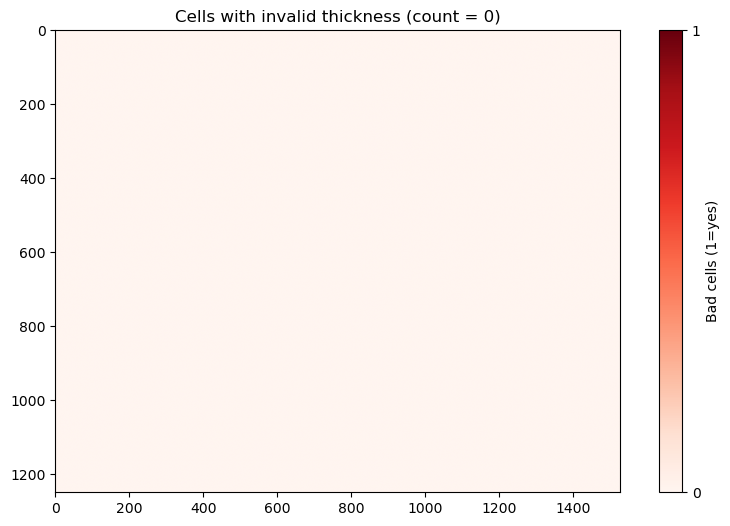

In [9]:
# Plot the layers to check bad cells
# Find where bad cells are located
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

bad_mask = bad.astype(np.uint8)  # 0/1 boolean to uint8

plt.figure(figsize=(10, 6))
plt.imshow(bad_mask, cmap="Reds", vmin=0, vmax=1)
plt.colorbar(label="Bad cells (1=yes)", ticks=[0, 1])
plt.title(f"Cells with invalid thickness (count = {bad_mask.sum()})")
plt.show()


In [10]:
thk = top2d - botm3d[0]
vals = thk[id2d == 1]
print("Thickness percentiles (m):", np.percentile(vals, [0, 1, 5, 50, 95, 99, 100]))

Thickness percentiles (m): [  69.88097382   74.82099915  173.76903076  254.24420166  487.14384155
  566.35052979 1036.35437012]


In [11]:
# 1) Make sure BOTM nodata isn’t sneaking into inactive/active cells
import numpy as np

print("Top finite fraction (active):", np.isfinite(top2d[id2d==1]).mean())
print("Botm finite fraction (active):", np.isfinite(botm3d[0][id2d==1]).mean())
print("HK finite fraction (active):", np.isfinite(hk3d[0][id2d==1]).mean())

print("Top min/max (active):", float(top2d[id2d==1].min()), float(top2d[id2d==1].max()))
print("Botm min/max (active):", float(botm3d[0][id2d==1].min()), float(botm3d[0][id2d==1].max()))
print("HK min/max (active):", float(hk3d[0][id2d==1].min()), float(hk3d[0][id2d==1].max()))


Top finite fraction (active): 1.0
Botm finite fraction (active): 1.0
HK finite fraction (active): 1.0
Top min/max (active): 69.88097381591797 1036.3543701171875
Botm min/max (active): 0.0 0.0
HK min/max (active): 9.99999993922529e-09 150.33599853515625


## 5-2) Make a 5-layer model to match the 5 HK bands

In [12]:
import numpy as np

# --- You have:
# top2d (nrow,ncol)
# botm_raw (bands,nrow,ncol) but currently 1 band
# hk_raw   (5,nrow,ncol) after your new HK_5band raster is aligned
# id2d     (nrow,ncol) 0/1

botm_base = botm3d[0]   # use the CLEANED single-band bottom          
thk_total = top2d - botm_base

# Fractions for 5 layers (must sum to 1.0)
fractions = np.array([0.15, 0.20, 0.25, 0.20, 0.20], dtype="float32")
fractions = fractions / fractions.sum()

# Enforce a minimum thickness per layer (m) so no razor-thin layers
min_thk = 5.0

# Build layer thicknesses
thk_layers = fractions[:, None, None] * thk_total[None, :, :]
thk_layers = np.maximum(thk_layers, min_thk)

# If total thickness is too small anywhere, deactivate those cells
bad_total = (id2d == 1) & (~np.isfinite(thk_total) | (thk_total <= (min_thk * 5)))
print("Cells with insufficient total thickness:", int(bad_total.sum()))
id2d = id2d.copy()
id2d[bad_total] = 0

# Recompute thk_total after deactivation (optional, just keeps things consistent)
thk_total = top2d - botm_base

# Rebuild layer thicknesses again (after id2d update)
thk_layers = fractions[:, None, None] * thk_total[None, :, :]
thk_layers = np.maximum(thk_layers, min_thk)

# Cumulative thickness to get bottoms
cum = np.cumsum(thk_layers, axis=0)
botm3d = top2d[None, :, :] - cum

# Force last bottom to match botm_base (optional but recommended)
botm3d[-1, :, :] = botm_base

# Set nlay to match HK bands (5)
nlay = hk_raw.shape[0]
print("Using nlay =", nlay, "to match HK bands")

# Now map HK directly (5 bands -> 5 layers)
hk3d = hk_raw.copy()

# Build idomain
idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

# Zero inactive
top2d[id2d == 0] = 0.0
botm3d[:, id2d == 0] = 0.0
hk3d[:, id2d == 0] = 0.0

# Clamp HK (active)
hk_min, hk_max = 1e-8, 1e4
m = (id2d == 1)
for k in range(nlay):
    hk3d[k, m] = np.clip(hk3d[k, m], hk_min, hk_max)
    hk3d[k, ~m] = 0.0

# Thickness check (all layers)
bad = np.zeros_like(id2d, dtype=bool)
thk1 = top2d - botm3d[0]
bad |= (id2d == 1) & (~np.isfinite(thk1) | (thk1 <= 0))
for k in range(1, nlay):
    thk = botm3d[k-1] - botm3d[k]
    bad |= (id2d == 1) & (~np.isfinite(thk) | (thk <= 0))

print("Bad thickness cells (after building 5 layers):", int(bad.sum()))
id2d[bad] = 0
idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

# Starting heads: (still use top if your start raster is a mask)
uvals = np.unique(start2d[id2d==1])[:10]
use_start = not (np.all(np.isin(uvals, [0.0, 1.0])) or (np.nanmax(start2d[id2d==1]) <= 2.0))
strt2d = start2d if use_start else top2d
strt = np.repeat(strt2d[np.newaxis, :, :], nlay, axis=0).astype("float32")
strt[idomain == 0] = 0.0

print("Active after 5-layer build:", int(np.count_nonzero(id2d)))
print("Using START raster for heads?", use_start)

Cells with insufficient total thickness: 0
Using nlay = 5 to match HK bands
Bad thickness cells (after building 5 layers): 0
Active after 5-layer build: 967433
Using START raster for heads? False


## 6) Build model grid + GridIntersect

In [13]:
structuredGrid = flopy.discretization.StructuredGrid(
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    xoff=xorigin, yoff=yorigin, angrot=0.0
)
ix = make_gridintersect(structuredGrid)
print("GridIntersect ready.")


GridIntersect ready.


## 7) Constant Head (CHD) cells from shoreline band

In [45]:
# Intersect CHD polygons and build weighted-head dataframe
dfChdIntsct = intersect_grid_feature(
    ix,
    pathInputConstHead,
    lay=0,
    addFields=[fieldInputConstHeadElev],
    grid_crs=grid_crs
)
print("CHD intersect rows:", dfChdIntsct.shape)
print("CHD intersect cols:", dfChdIntsct.columns.tolist())

def build_dfChd(dfChdIntsct, head_field, id2d):
    df = dfChdIntsct.copy()
    df = df.rename(columns={head_field: "head"})
    df["head"] = pd.to_numeric(df["head"], errors="coerce")

    wcol = "areas" if "areas" in df.columns else ("lengths" if "lengths" in df.columns else None)

    if wcol:
        df[wcol] = pd.to_numeric(df[wcol], errors="coerce").fillna(0.0).astype(float)
        df["wh"] = df["head"].astype(float) * df[wcol]
        gsum = (df.groupby("cellids", as_index=False)
                  .agg(row=("row","min"), col=("col","min"),
                       wsum=(wcol,"sum"), whsum=("wh","sum"),
                       head_mean=("head","mean")))
        gsum["head"] = np.where(gsum["wsum"]>0, gsum["whsum"]/gsum["wsum"], gsum["head_mean"])
        out = gsum[["cellids","row","col","head"]].copy()
    else:
        out = (df.groupby("cellids", as_index=False)
                 .agg(row=("row","min"), col=("col","min"), head=("head","mean")))

    r = out["row"].astype(int).to_numpy()
    c = out["col"].astype(int).to_numpy()
    out = out.loc[id2d[r,c] == 1].copy()
    out["lay"] = 0
    return out[["cellids","lay","row","col","head"]]

dfChd = build_dfChd(dfChdIntsct, fieldInputConstHeadElev, id2d)
print("dfChd:", dfChd.shape, "head min/max:", float(dfChd["head"].min()), float(dfChd["head"].max()))
print(dfChd.head())

# MF6 CHD records
chd_rec = [((int(r["lay"]), int(r["row"]), int(r["col"])), float(r["head"]))
           for _, r in dfChd.iterrows()]


CHD intersect rows: (24385, 7)
CHD intersect cols: ['cellids', 'cellid', 'row', 'col', 'ixshapes', 'areas', 'Elev']
dfChd: (24370, 5) head min/max: 175.0 175.0
         cellids  lay  row  col   head
0  (0, 215, 432)    0  215  432  175.0
1  (0, 215, 433)    0  215  433  175.0
2  (0, 215, 434)    0  215  434  175.0
3  (0, 215, 435)    0  215  435  175.0
4  (0, 215, 436)    0  215  436  175.0


In [49]:
# --- FIX: drop CHD cells where head is below the layer-1 bottom ---
eps = 0.01  # small buffer (m)

rr = dfChd["row"].astype(int).to_numpy()
cc = dfChd["col"].astype(int).to_numpy()

botm0 = botm3d[0, rr, cc]  # bottom of layer 1 at those CHD cells
ok = dfChd["head"].to_numpy(dtype=float) >= (botm0 + eps)

print("CHD cells before:", len(dfChd))
print("CHD cells dropped (head < botm):", int((~ok).sum()))
dfChd = dfChd.loc[ok].copy()
print("CHD cells after:", len(dfChd))

# rebuild records
chd_rec = [((int(r["lay"]), int(r["row"]), int(r["col"])), float(r["head"]))
           for _, r in dfChd.iterrows()]

CHD cells before: 24370
CHD cells dropped (head < botm): 4189
CHD cells after: 20181


## 8) Drains (DRN) from stream lines: length + width → conductance

In [6]:
import fiona

gdb_path = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_tmp.gdb"
print(fiona.listlayers(gdb_path)[:30])  # show first layers

['streams_3174', 'template_extent', 'streams_3174_clip']


In [16]:
import geopandas as gpd
import rasterio as rio
from shapely.geometry import box

gdb_path = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_tmp.gdb"
layer_name = "streams_3174"   # <- must match listlayers output exactly

with rio.open(template_tif) as src:
    b = src.bounds
    bbox = box(b.left, b.bottom, b.right, b.top)

# Use engine="fiona" (often more reliable for FileGDB than pyogrio on some installs)
gdf = gpd.read_file(
    gdb_path,
    layer=layer_name,
    bbox=bbox,
    columns=[fieldInputDrnWidth],   # <-- only attribute columns
    engine="fiona",
)
print("Loaded:", len(gdf), "CRS:", gdf.crs)
print(gdf.head())

Loaded: 1658260 CRS: EPSG:3174
   WIDTH_M                                           geometry
0     25.0  MULTILINESTRING Z ((913782.041 1405211.372 0, ...
1     10.0  MULTILINESTRING Z ((913319.239 1396308.186 0, ...
2     25.0  MULTILINESTRING Z ((912330.631 1391508.056 0, ...
3     10.0  MULTILINESTRING Z ((910049.536 1388163.939 0, ...
4     10.0  MULTILINESTRING Z ((910264.389 1418607.847 0, ...


In [58]:
def build_drn_from_streams_option1_fast(
    ix,
    gdb_path,
    layer_name,
    template_tif,
    id2d,
    top2d,
    hk3d,
    width_field="WIDTH_M",
    lay=0,
    default_width=10.0,
    bed_thick=1.0,
    elev_offset=0.5,
    chunk_size=500,
    simplify_tol=None,

    # ✅ NEW: controls to reduce DRN size + strength
    min_len=100.0,       # meters; drop cells with tiny stream length
    cond_mult=0.05,      # multiply cond by this (0.01–0.1 typical)
    cond_cap=1e5,        # cap max conductance
):
    """
    Fast drains:
      - reads only streams inside model bbox (bbox read from FileGDB layer)
      - chunks features into MultiLineString (supported by FloPy GridIntersect)
      - intersects each chunk to get per-cell lengths
      - uses a single representative width (median) for all drains
    Returns:
      dfDrn (DataFrame) and drn_rec (MF6 DRN records)
    """

    # --- model bbox (in grid CRS) ---
    with rio.open(template_tif) as src:
        b = src.bounds
        bbox_tuple = (b.left, b.bottom, b.right, b.top)

    # --- read only features in bbox (huge speedup) ---
    gdf = gpd.read_file(
        gdb_path,
        layer=layer_name,
        bbox=bbox_tuple,
        engine="fiona",
    )

    if gdf.empty:
        raise RuntimeError("No stream features read in model bbox. Check layer_name / bbox / CRS.")

    # keep only valid lines
    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()
    gdf = gdf[gdf.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()
    if gdf.empty:
        raise RuntimeError("No LineString/MultiLineString geometries remain after filtering.")

    # optional simplify (reduce vertices)
    if simplify_tol is not None and simplify_tol > 0:
        gdf["geometry"] = gdf.geometry.simplify(simplify_tol, preserve_topology=False)
        gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

    print("Streams loaded (bbox):", len(gdf))

    # representative width
    if width_field in gdf.columns:
        w = pd.to_numeric(gdf[width_field], errors="coerce")
        width_m = float(np.nanmedian(w.values)) if np.isfinite(w).any() else float(default_width)
    else:
        width_m = float(default_width)

    if (not np.isfinite(width_m)) or (width_m <= 0):
        width_m = float(default_width)

    print("Using representative width_m:", width_m)

    geoms = gdf.geometry.values
    parts = []

    for start in range(0, len(geoms), chunk_size):
        chunk_geoms = geoms[start:start + chunk_size]

        # flatten into list of LineStrings
        lines = []
        for g in chunk_geoms:
            if g is None or g.is_empty:
                continue
            if g.geom_type == "LineString":
                lines.append(g)
            elif g.geom_type == "MultiLineString":
                lines.extend(list(g.geoms))

        if not lines:
            continue

        mls = MultiLineString(lines)

        try:
            out = ix.intersect(mls, geo_dataframe=False)
        except TypeError:
            out = ix.intersect(mls)

        df = pd.DataFrame(out)
        if df.empty:
            continue

        if "lengths" not in df.columns:
            if "length" in df.columns:
                df = df.rename(columns={"length": "lengths"})
            else:
                raise RuntimeError(f"No lengths column. Got: {df.columns.tolist()}")

        # add (lay,row,col)
        df["cellids"] = df["cellids"].apply(lambda rc: (lay, rc[0], rc[1]))
        df["row"] = df["cellids"].apply(lambda x: x[1])
        df["col"] = df["cellids"].apply(lambda x: x[2])
        df["width_m"] = width_m

        parts.append(df)

        if (start // chunk_size) % 10 == 0:
            print(f"  intersected {min(start + chunk_size, len(geoms))}/{len(geoms)} features...")

    if not parts:
        raise RuntimeError("No DRN intersections found after chunked MultiLineString intersect.")

    dfIntsct = pd.concat(parts, ignore_index=True)

    # merge per cell
    dfIntsct["lengths"] = pd.to_numeric(dfIntsct["lengths"], errors="coerce").fillna(0.0)
    dfDrn = (dfIntsct.groupby("cellids", as_index=False)
             .agg(row=("row", "min"),
                  col=("col", "min"),
                  lengths=("lengths", "sum"),
                  width_m=("width_m", "mean")))

    # ✅ NEW: drop tiny stream lengths per cell (big reduction in DRN count)
    if min_len is not None and min_len > 0:
        before = len(dfDrn)
        dfDrn = dfDrn.loc[dfDrn["lengths"] >= float(min_len)].copy()
        print(f"Drop tiny lengths < {min_len} m: {before} -> {len(dfDrn)} cells")

    # filter to active
    r = dfDrn["row"].astype(int).to_numpy()
    c = dfDrn["col"].astype(int).to_numpy()
    dfDrn = dfDrn.loc[id2d[r, c] == 1].copy()
    dfDrn["lay"] = lay

    # conductance + elevation
    rows = dfDrn["row"].astype(int).to_numpy()
    cols = dfDrn["col"].astype(int).to_numpy()

    K = hk3d[lay, rows, cols].astype("float32")
    TOP = top2d[rows, cols].astype("float32")

    L = dfDrn["lengths"].to_numpy(dtype="float32")
    W = dfDrn["width_m"].to_numpy(dtype="float32")

    cond = K * (W * L) / float(bed_thick)
    elev = TOP - float(elev_offset)

    dfDrn["cond"] = np.nan_to_num(cond, nan=0.0, posinf=0.0, neginf=0.0)
    dfDrn["elev"] = np.nan_to_num(elev, nan=0.0, posinf=0.0, neginf=0.0)

    # ✅ NEW: scale + cap conductance (stabilizes the run)
    dfDrn["cond"] = dfDrn["cond"] * float(cond_mult)
    if cond_cap is not None:
        dfDrn["cond"] = np.minimum(dfDrn["cond"], float(cond_cap))

    # final cleanup
    dfDrn = dfDrn.loc[dfDrn["cond"] > 0].copy()

    drn_rec = [((int(r["lay"]), int(r["row"]), int(r["col"])),
                float(r["elev"]), float(r["cond"]))
               for _, r in dfDrn.iterrows()]

    print("DRN cells:", len(dfDrn),
          "cond min/max:", float(dfDrn["cond"].min()), float(dfDrn["cond"].max()))
    return dfDrn, drn_rec

In [59]:
# ----------------------------
# USAGE (FULL, SAFE)
# ----------------------------

# Example: set these to your real values
# gdb_path = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_tmp.gdb"
# layer_name = "streams_3174_subset"   # or "streams_3174"

fDrn, drn_rec = build_drn_from_streams_option1_fast(
    ix=ix,
    gdb_path=gdb_path,
    layer_name=layer_name,
    template_tif=template_tif,
    id2d=id2d,
    top2d=top2d,
    hk3d=hk3d,
    width_field="WIDTH_M",
    lay=0,
    bed_thick=1.0,
    elev_offset=0.5,
    simplify_tol=100.0,

    # key tuning knobs:
    min_len=100.0,
    cond_mult=0.05,
    cond_cap=1e5,
)

# Remove overlap with CHD ONLY if dfChd exists (prevents NameError)
if "dfChd" in globals() and dfChd is not None and (not dfChd.empty):
    dfDrn = dfDrn.loc[~dfDrn["cellids"].isin(dfChd["cellids"])].copy()

# Rebuild records after optional filter
drn_rec = [((int(r["lay"]), int(r["row"]), int(r["col"])),
            float(r["elev"]), float(r["cond"]))
           for _, r in dfDrn.iterrows()]

print("Final DRN records:", len(drn_rec), "example:", drn_rec[0] if drn_rec else None)

Streams loaded (bbox): 1658260
Using representative width_m: 10.0
  intersected 500/1658260 features...
  intersected 5500/1658260 features...
  intersected 10500/1658260 features...
  intersected 15500/1658260 features...
  intersected 20500/1658260 features...
  intersected 25500/1658260 features...
  intersected 30500/1658260 features...
  intersected 35500/1658260 features...
  intersected 40500/1658260 features...
  intersected 45500/1658260 features...
  intersected 50500/1658260 features...
  intersected 55500/1658260 features...
  intersected 60500/1658260 features...
  intersected 65500/1658260 features...
  intersected 70500/1658260 features...
  intersected 75500/1658260 features...
  intersected 80500/1658260 features...
  intersected 85500/1658260 features...
  intersected 90500/1658260 features...
  intersected 95500/1658260 features...
  intersected 100500/1658260 features...
  intersected 105500/1658260 features...
  intersected 110500/1658260 features...
  intersected 

## 9) Time discretization (monthly 2000–2025) + recharge dictionary from NLDAS `Qsb`

In [33]:
def build_monthly_perioddata(start="2000-01-02", end="2025-12-01", nstp=1, tsmult=1.0):
    months = pd.date_range(start=start, end=end, freq="MS")
    pddata = []
    for d in months:
        ndays = calendar.monthrange(d.year, d.month)[1]
        pddata.append((float(ndays), int(nstp), float(tsmult)))
    return pddata, months

perioddata, months = build_monthly_perioddata("2000-01-01", "2025-12-01")
nper = len(perioddata)
print("Stress periods:", nper)

df_nc = index_blend_qsb_monthlies(nldas_root)
expected = pd.date_range("2000-01-01", "2025-12-01", freq="MS")
missing = expected.difference(df_nc["date"])
print("Missing months:", len(missing))
if len(missing) > 0:
    print("First missing:", list(missing[:10]))

# Optional speed test: run only first N periods (set to None for full run)
NPER_TEST = 12  # set None for full 312
if NPER_TEST is not None:
    perioddata_run = perioddata[:NPER_TEST]
    df_nc_run = df_nc.iloc[:NPER_TEST].copy()
else:
    perioddata_run = perioddata
    df_nc_run = df_nc

print("Running nper =", len(perioddata_run))


Stress periods: 312
Missing months: 0
Running nper = 12


In [38]:
# Build recharge arrays on the template grid
rch_spd = {}
bad = []

for per, (dt, pth) in enumerate(zip(df_nc_run["date"], df_nc_run["path"])):
    try:
        rch_spd[per] = qsb_month_to_rech_mday_on_template(
            pth, template_tif, var="Qsb", id2d=id2d
        )
    except Exception as e:
        bad.append((per, str(dt.date()), pth, repr(e)))
        rch_spd[per] = np.zeros((nrow, ncol), dtype="float32")

print("Recharge built:", len(rch_spd), "bad:", len(bad))
if bad:
    print("Example bad:", bad[0])

# quick sanity stats
a0 = rch_spd[0]
print("rch[0] min/max:", float(a0.min()), float(a0.max()))


Recharge built: 12 bad: 0
rch[0] min/max: 0.0 0.001873785862699151


## 10) Build MF6 simulation cleanly + write + run
This section deletes and recreates the workspace each time to avoid stale/truncated package files.

In [46]:
# Rebuild chd_rec from dfChd (if dfChd exists)
if "dfChd" not in globals() or dfChd is None or dfChd.empty:
    raise NameError("dfChd is not defined. Run the CHD intersection cell to create dfChd first.")

chd_rec = list(zip(
    list(zip(dfChd["lay"].astype(int), dfChd["row"].astype(int), dfChd["col"].astype(int))),
    dfChd["head"].astype(float)
))
print("Built chd_rec:", len(chd_rec), "example:", chd_rec[0])

Built chd_rec: 24370 example: ((0, 215, 432), 175.0)


In [52]:
rch_spd_test = {k: (0.25 * v).astype("float32") for k, v in rch_spd.items()}  # 25% of current

In [53]:
dfDrn["cond"] = dfDrn["cond"] * 0.1   # start with 10% strength
drn_rec = [((int(r["lay"]), int(r["row"]), int(r["col"])), float(r["elev"]), float(r["cond"]))
           for _, r in dfDrn.iterrows()]

In [70]:
import os, shutil, gc, time
from pathlib import Path

# --- 0) close any open flopy binary handles (common culprit) ---
# If you have variables named like these from earlier cells, close them:
for varname in ["cbc", "hds", "bud", "headfile", "cellbudgetfile"]:
    obj = globals().get(varname, None)
    try:
        # CellBudgetFile/HeadFile have .close() in recent flopy
        if obj is not None and hasattr(obj, "close"):
            obj.close()
            print(f"Closed {varname}")
    except Exception as e:
        print(f"Could not close {varname}:", repr(e))

# also force garbage collection (releases file handles)
gc.collect()
time.sleep(0.5)

# --- 1) robust folder delete (handles read-only + retries) ---
def _rm_readonly(func, path, exc_info):
    # make file writable then retry
    try:
        os.chmod(path, 0o666)
    except Exception:
        pass
    func(path)

def safe_rmtree(path, retries=8, wait=0.5):
    path = str(path)
    for i in range(retries):
        if not os.path.exists(path):
            return
        try:
            shutil.rmtree(path, onerror=_rm_readonly)
            return
        except PermissionError as e:
            print(f"Retry {i+1}/{retries} delete failed (file locked). Waiting {wait}s...")
            time.sleep(wait)
            gc.collect()
    # final attempt: raise
    shutil.rmtree(path, onerror=_rm_readonly)

# --- 2) now clean workspace ---
if os.path.isdir(sim_ws):
    safe_rmtree(sim_ws)

os.makedirs(sim_ws, exist_ok=True)
print("Workspace cleaned:", sim_ws)

Closed cbc
Closed hds
Workspace cleaned: D:\Users\abolmaal\modelling\Modflow\Testing


In [72]:
# -----------------------
# 0) Clean workspace
# -----------------------
if os.path.isdir(sim_ws):
    shutil.rmtree(sim_ws)
os.makedirs(sim_ws, exist_ok=True)

# -----------------------
# 1) NEW simulation object (prevents "already exists" warnings)
# -----------------------
sim = flopy.mf6.MFSimulation(sim_name=nameSim, sim_ws=sim_ws, exe_name=exe_path)

# -----------------------
# 2) TDIS
# -----------------------
tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    nper=len(perioddata_run),
    perioddata=perioddata_run,
    start_date_time="2000-01-01",
)

# -----------------------
# 3) IMS (solver)
# -----------------------
ims = flopy.mf6.ModflowIms(
    sim,
    pname="ims",
    complexity="MODERATE",
    outer_maximum=100,
    inner_maximum=200,
    outer_dvclose=1e-2,
    inner_dvclose=1e-2,
    rcloserecord=1e-2,
    linear_acceleration="BICGSTAB",
    under_relaxation="DBD",
    print_option="SUMMARY",
    filename=f"{nameModel}.ims",
)

# -----------------------
# 4) GWF model
# -----------------------
gwf = flopy.mf6.ModflowGwf(sim, modelname=nameModel, save_flows=True)

# IMPORTANT: register IMS AFTER gwf exists
sim.register_ims_package(ims, [gwf.name])

# -----------------------
# 5) DIS
# -----------------------
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    top=top2d,
    botm=botm3d,
    idomain=idomain,
    xorigin=xorigin, yorigin=yorigin,
)

# -----------------------
# 6) NPF
# -----------------------
icelltype = [1] + [0]*(nlay-1)  # safe even if nlay changes
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=icelltype,
    k=hk3d,
    save_specific_discharge=True,
)

# -----------------------
# 7) IC
# -----------------------
ic = flopy.mf6.ModflowGwfic(gwf, strt=strt)

# -----------------------
# 8) STO
# -----------------------
sto = flopy.mf6.ModflowGwfsto(
    gwf,
    ss=1e-6,
    sy=0.1,
    steady_state=False,
    transient=True,
)

# -----------------------
# 9) OC
# -----------------------
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{nameModel}.hds",
    budget_filerecord=f"{nameModel}.cbb",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
)

# -----------------------
# 10) CHD / DRN (constant in time -> ONLY period 0)
# -----------------------
chd_spd = {0: chd_rec}
drn_spd = {0: drn_rec}

chd = flopy.mf6.ModflowGwfchd(
    gwf, pname="CHD", filename=f"{nameModel}.chd",
    stress_period_data=chd_spd
)

drn = flopy.mf6.ModflowGwfdrn(
    gwf, pname="DRN", filename=f"{nameModel}.drn",
    stress_period_data=drn_spd
)

# -----------------------
# 11) RCHA (array recharge)
# -----------------------
rcha = flopy.mf6.ModflowGwfrcha(
    gwf,
    pname="RCHA",
    filename=f"{nameModel}.rcha",
    recharge=rch_spd,
)

# -----------------------
# 12) Write + run
# -----------------------
sim.write_simulation()

rcha_path = os.path.join(sim_ws, f"{nameModel}.rcha")
print("RCHA exists?", os.path.exists(rcha_path),
      "size:", os.path.getsize(rcha_path) if os.path.exists(rcha_path) else None)

ok, buff = sim.run_simulation()
print("Run success:", ok)
if not ok:
    print("\n".join(buff[-120:]))

# helpful tails
lst_sim = Path(sim_ws) / "mfsim.lst"
if lst_sim.exists():
    print("\n--- mfsim.lst tail ---")
    print("\n".join(lst_sim.read_text(errors="ignore").splitlines()[-120:]))

lst_model = Path(sim_ws) / f"{nameModel}.lst"
if lst_model.exists():
    print(f"\n--- {nameModel}.lst tail ---")
    print("\n".join(lst_model.read_text(errors="ignore").splitlines()[-200:]))


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model Testing...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package sto...
    writing package oc...
    writing package chd...
INFORMATION: maxbound in ('', 'chd', 'dimensions') changed to 20181 based on size of stress_period_data
    writing package drn...
INFORMATION: maxbound in ('', 'drn', 'dimensions') changed to 518398 based on size of stress_period_data
    writing package rcha...
RCHA exists? True size: 382001406
FloPy is using the following executable to run the model: ..\helper\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.3 09/29/2025

   MODFLOW 6 compiled Oct 07 2025 23:07:48 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications runn

In [107]:
from pathlib import Path
import os, shutil, gc
import flopy
import numpy as np

# 1) NEW workspace (do NOT reuse the old one)
sim_ws = r"D:\Users\abolmaal\modelling\Modflow\Testing_5km"
ws = Path(sim_ws)

# If you want to delete, make sure files are not open (close HeadFile/CellBudgetFile first)
gc.collect()
if ws.exists():
    shutil.rmtree(ws, ignore_errors=True)   # if Windows locks, just change folder name instead
ws.mkdir(parents=True, exist_ok=True)

# 2) HARD CHECKS BEFORE YOU BUILD DIS
nlay = botm3d.shape[0] if botm3d.ndim == 3 else 1
nrow, ncol = top2d.shape

assert top2d.shape == (nrow, ncol)
assert idomain.shape == (nlay, nrow, ncol)
assert botm3d.shape == (nlay, nrow, ncol)
assert hk3d.shape == (nlay, nrow, ncol)

# 3) NEW simulation object every time (prevents "already exists" warnings)
sim = flopy.mf6.MFSimulation(sim_name=nameSim, sim_ws=str(ws), exe_name=exe_path)

tdis = flopy.mf6.ModflowTdis(
    sim, time_units="DAYS",
    nper=len(perioddata_run), perioddata=perioddata_run,
    start_date_time="2000-01-01"
)

ims = flopy.mf6.ModflowIms(
    sim, pname="ims",
    complexity="MODERATE",
    outer_maximum=100,
    inner_maximum=200,
    outer_dvclose=1e-2,
    inner_dvclose=1e-2,
    rcloserecord=1e-2,
    linear_acceleration="BICGSTAB",
    under_relaxation="DBD",
    print_option="SUMMARY",
)

gwf = flopy.mf6.ModflowGwf(sim, modelname=nameModel, save_flows=True)
sim.register_ims_package(ims, [gwf.name])  # register AFTER gwf exists

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    top=top2d,
    botm=botm3d,
    idomain=idomain,
    xorigin=xorigin, yorigin=yorigin
)

npf = flopy.mf6.ModflowGwfnpf(
    gwf, icelltype=[1] + [0]*(nlay-1),
    k=hk3d,
    save_specific_discharge=True
)

ic  = flopy.mf6.ModflowGwfic(gwf, strt=strt)
sto = flopy.mf6.ModflowGwfsto(gwf, ss=1e-6, sy=0.1, steady_state=False, transient=True)

oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{nameModel}.hds",
    budget_filerecord=f"{nameModel}.cbb",
    saverecord=[("HEAD","ALL"), ("BUDGET","ALL")],
    printrecord=[("HEAD","LAST"), ("BUDGET","LAST")]
)

nper_run = len(perioddata_run)
chd = flopy.mf6.ModflowGwfchd(gwf, stress_period_data={per: chd_rec for per in range(nper_run)})
drn = flopy.mf6.ModflowGwfdrn(gwf, stress_period_data={per: drn_rec for per in range(nper_run)})

# IMPORTANT: MF6 recharge is RCHA for arrays
rcha = flopy.mf6.ModflowGwfrcha(
    gwf, pname="RCHA", filename=f"{nameModel}.rcha", recharge=rch_spd
)

sim.write_simulation()
ok, buff = sim.run_simulation()
print("Run success:", ok)
if not ok:
    print("\n".join(buff[-80:]))

MFDataException: An error occurred in data element "delr" model "Testing" package "dis". The error occurred while setting data in the "__init__" method.
Additional Information:
(1) Unable to set data "delr" layer 0.  Data is not in a valid format.
(2) Error occurred while adding dataset "delr" to block "griddata"

# Visualizing the results

In [73]:
import os
from pathlib import Path

ws = Path(sim_ws)
print("hds:", (ws / f"{nameModel}.hds").exists(), (ws / f"{nameModel}.hds").stat().st_size)
print("cbb:", (ws / f"{nameModel}.cbb").exists(), (ws / f"{nameModel}.cbb").stat().st_size)
print("lst:", (ws / f"{nameModel}.lst").exists(), (ws / f"{nameModel}.lst").stat().st_size)

hds: True 183094032
cbb: True 1400339808
lst: True 290756978


n head times: 12 first: (np.int32(0), np.int32(0)) last: (np.int32(0), np.int32(11))
head first: min=69.535 p1=98.798 p5=173.692 med=248.267 p95=473.801 p99=551.245 max=1082.901
head last: min=69.512 p1=100.136 p5=173.648 med=250.998 p95=479.515 p99=638.860 max=7513.461
cells above 99.9%: 968
example outliers (row,col,head):
499 527 2497.0414096236086
499 528 2496.582321342831
499 529 2498.095372521116
499 531 2242.3300412231724
500 528 2497.434205763864
500 529 2499.0160226098915
500 531 2104.6427265709717
501 528 2498.2320864613143
501 529 2499.1021565306246
501 531 2095.5997428315677


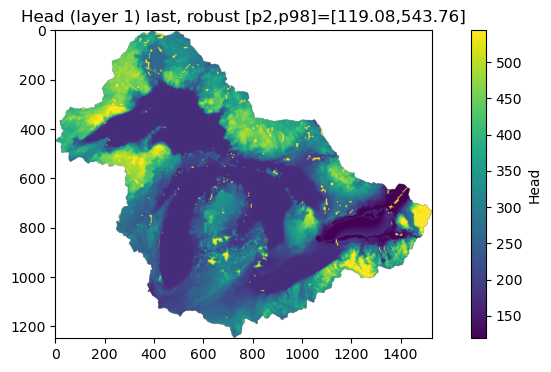

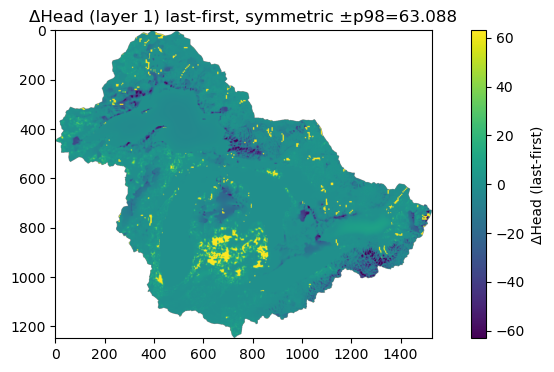

In [81]:
import os
import numpy as np
import flopy
import matplotlib.pyplot as plt

hds_path = os.path.join(sim_ws, f"{nameModel}.hds")
hds = flopy.utils.HeadFile(hds_path)

kstpkper_list = hds.get_kstpkper()
print("n head times:", len(kstpkper_list), "first:", kstpkper_list[0], "last:", kstpkper_list[-1])

# layer to view
k = 0

h_first = hds.get_data(kstpkper=kstpkper_list[0])[k].copy()
h_last  = hds.get_data(kstpkper=kstpkper_list[-1])[k].copy()

# mask inactive
mask = (idomain[k] == 0)
h_first[mask] = np.nan
h_last[mask]  = np.nan

def statline(a, name):
    p = np.nanpercentile(a, [0, 1, 5, 50, 95, 99, 100])
    print(f"{name}: min={p[0]:.3f} p1={p[1]:.3f} p5={p[2]:.3f} "
          f"med={p[3]:.3f} p95={p[4]:.3f} p99={p[5]:.3f} max={p[6]:.3f}")

statline(h_first, "head first")
statline(h_last,  "head last")

# where are the extreme values that stretch the colorbar?
thr = np.nanpercentile(h_last, 99.9)
rr, cc = np.where(h_last > thr)
print("cells above 99.9%:", len(rr))
if len(rr) > 0:
    show = min(10, len(rr))
    print("example outliers (row,col,head):")
    for i in range(show):
        print(int(rr[i]), int(cc[i]), float(h_last[rr[i], cc[i]]))

# --- Plot head with ROBUST limits (so you can see spatial structure) ---
vmin, vmax = np.nanpercentile(h_last, [2, 98])
plt.figure(figsize=(10,4))
plt.imshow(h_last, vmin=vmin, vmax=vmax)
plt.colorbar(label="Head")
plt.title(f"Head (layer {k+1}) last, robust [p2,p98]=[{vmin:.2f},{vmax:.2f}]")
plt.show()

# --- Plot head change (last - first) with symmetric robust limits ---
dh = h_last - h_first
lim = np.nanpercentile(np.abs(dh), 98)
plt.figure(figsize=(10,4))
plt.imshow(dh, vmin=-lim, vmax=lim)
plt.colorbar(label="ΔHead (last-first)")
plt.title(f"ΔHead (layer {k+1}) last-first, symmetric ±p98={lim:.3f}")
plt.show()

hds.close()

In [93]:
# tep 2 — Compare outlier heads to TOP/BOTM and K

# you already have h_last from the diagnostic cell
thr = np.nanpercentile(h_last, 99.9)
rr, cc = np.where(h_last > thr)

out_cellids = {(0, int(r), int(c)) for r, c in zip(rr, cc)}  # layer 1 only

# build CHD/DRN sets from your existing records
chd_cells = {cid for (cid, head) in chd_rec}                        # ((lay,row,col), head)
drn_cells = {cid for (cid, elev, cond) in drn_rec}                  # ((lay,row,col), elev, cond)

n_out = len(out_cellids)
n_out_chd = len(out_cellids & chd_cells)
n_out_drn = len(out_cellids & drn_cells)

print("Outliers (99.9%):", n_out)
print("Outliers that are CHD cells:", n_out_chd, f"({100*n_out_chd/n_out:.1f}%)")
print("Outliers that are DRN cells:", n_out_drn, f"({100*n_out_drn/n_out:.1f}%)")

Outliers (99.9%): 968
Outliers that are CHD cells: 0 (0.0%)
Outliers that are DRN cells: 581 (60.0%)


In [94]:
print("head_last:", head_last.shape)
print("top2d:", top2d.shape)
print("idomain layer0:", idomain[0].shape)
print("botm3d layer0:", botm3d[0].shape)

head_last: (1249, 1527)
top2d: (250, 305)
idomain layer0: (250, 305)
botm3d layer0: (250, 305)


In [105]:
from pathlib import Path
import numpy as np
import flopy
from flopy.mf6.utils import MfGrdFile

ws = Path(sim_ws).resolve()
print("sim_ws =", ws)

grb_path = ws / "Testing.dis.grb"   # or f"{nameModel}.dis.grb"
print("grb exists:", grb_path.exists(), grb_path)

grb = MfGrdFile(str(grb_path))
print("GRB grid:", (grb.nlay, grb.nrow, grb.ncol))

print("Your arrays:")
print("  top2d:", top2d.shape)
print("  idomain[0]:", idomain[0].shape)
print("  botm3d[0]:", botm3d[0].shape)

sim_ws = D:\Users\abolmaal\modelling\Modflow\Testing
grb exists: True D:\Users\abolmaal\modelling\Modflow\Testing\Testing.dis.grb
GRB grid: (np.int32(1), np.int32(1249), np.int32(1527))
Your arrays:
  top2d: (250, 305)
  idomain[0]: (250, 305)
  botm3d[0]: (250, 305)


In [106]:
hds_path = ws / "Testing.hds"   # or ws / f"{nameModel}.hds"
print("hds exists:", hds_path.exists(), "size MB:", hds_path.stat().st_size/1e6)

hds = flopy.utils.HeadFile(str(hds_path))
kstpkper_last = hds.get_kstpkper()[-1]
h3d = hds.get_data(kstpkper=kstpkper_last)   # (nlay,nrow,ncol)
hds.close()

print("HDS shape:", h3d.shape, "last kstpkper:", kstpkper_last)

hds exists: True size MB: 183.094032
HDS shape: (1, 1249, 1527) last kstpkper: (np.int32(0), np.int32(11))


In [102]:
from pathlib import Path
import flopy
import numpy as np

print("sim_ws =", sim_ws)
hds_path = Path(sim_ws) / f"{nameModel}.hds"
print("hds_path =", hds_path)
print("exists =", hds_path.exists())
if hds_path.exists():
    st = hds_path.stat()
    print("size_MB =", st.st_size/1e6, "modified =", st.st_mtime)

# list all head files near your workspace (helps catch “wrong folder” issues)
print("\nAll .hds in sim_ws:")
for p in Path(sim_ws).glob("*.hds"):
    print(" -", p.name, p.stat().st_size/1e6, "MB")

# read head shape
hds = flopy.utils.HeadFile(str(hds_path))
kstpkper_last = hds.get_kstpkper()[-1]
h = hds.get_data(kstpkper=kstpkper_last)
hds.close()

print("\nHead array shape from file:", h.shape)
print("Expected (nlay,nrow,ncol):", (nlay, nrow, ncol))
print("top2d:", top2d.shape, "idomain0:", idomain[0].shape, "botm0:", botm3d[0].shape)

# hard fail if mismatch (so you don't keep diagnosing the wrong grid)
if h.shape != (nlay, nrow, ncol):
    raise ValueError("STOP: head file shape does not match your DIS grid. You are reading the wrong .hds (or mixing grids).")

sim_ws = D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\mf6_transient
hds_path = D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\mf6_transient\gwf_glb.hds
exists = True
size_MB = 0.0 modified = 1772130211.3830981

All .hds in sim_ws:
 - gwf_glb.hds 0.0 MB


ValueError: datafile error: file is empty: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\mf6_transient\gwf_glb.hds

## 11) If run fails: isolate which package breaks it
Run these in order until you see which package triggers the error.

In [ ]:
def run_with_packages(use_chd=True, use_drn=True, use_rch=True):
    # remove if exists
    for p in list(gwf.packagelist):
        ptype = getattr(p, "package_type", "").lower()
        if ptype in ("chd","drn","rch","rcha"):
            gwf.remove_package(p.package_name)

    nper_run = len(perioddata_run)
    if use_chd:
        _ = flopy.mf6.ModflowGwfchd(gwf, pname="CHD", filename=f"{nameModel}.chd", stress_period_data={per: chd_rec for per in range(nper_run)})
    if use_drn:
        _ = flopy.mf6.ModflowGwfdrn(gwf, pname="DRN", filename=f"{nameModel}.drn", stress_period_data={per: drn_rec for per in range(nper_run)})
    if use_rch:
        _ = flopy.mf6.ModflowGwfrch(gwf, pname="RCH", filename=f"{nameModel}.rch", recharge=rch_spd)

    sim.write_simulation()
    ok, buff = sim.run_simulation()
    print("ok:", ok, "| CHD:", use_chd, "DRN:", use_drn, "RCH:", use_rch)
    if not ok:
        print("\n".join(buff[-60:]))
    return ok

# Examples:
# run_with_packages(use_chd=False, use_drn=False, use_rch=False)  # base only
# run_with_packages(use_chd=True,  use_drn=False, use_rch=False)  # add CHD
# run_with_packages(use_chd=True,  use_drn=True,  use_rch=False)  # add DRN
# run_with_packages(use_chd=True,  use_drn=True,  use_rch=True)   # add RCH
